Title: LEE_Results_Analysis.ipynb

Purpose: Look at the found LEE Events

Author: Onno Nennecke on 16.07.2025 Modified: 16.07.2025

Input data: 

- LEE Tables    - This file lies here: 

Output data:

- Plots?    - This file lies here: 

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import os
import glob

from datetime import datetime

# Importing functions

### Read LEE data

In [ ]:
# Read the LEE data
LEE_dat = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv')

LEE_dat_7_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7.csv')
LEE_7 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection.csv')

LEE_dat_14_all = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14.csv')
LEE_14 = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection.csv')

LEE_vl = pd.read_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl.csv')


---

### Check doy distribution

In [3]:
# Remove all SMARD and ERA5_wwd data from the LEE_dat DataFrame
LEE_dat = LEE_dat[(LEE_dat['ESM'] != 'SMARD') & (LEE_dat['ESM'] != 'ERA5_wwd')]
LEE_7 = LEE_7[(LEE_7['ESM'] != 'SMARD') & (LEE_7['ESM'] != 'ERA5_wwd')]
LEE_14 = LEE_14[(LEE_14['ESM'] != 'SMARD') & (LEE_14['ESM'] != 'ERA5_wwd')]
LEE_vl = LEE_vl[(LEE_vl['ESM'] != 'SMARD') & (LEE_vl['ESM'] != 'ERA5_wwd')]


In [29]:
LEE_vl['date_start'][0]

'2015-01-05'

In [ ]:
# Function to create a list of dates from start_date to end_date from the LEE data
def create_date_list(LEE_data):
    """
    Generates a list of date strings from the start_date to end_date
    for each event in the LEE_data DataFrame.

    Parameters:
        LEE_data (pd.DataFrame): A DataFrame containing 'date_start' and 'date_end' columns.

    Returns:
        list: A list of date strings in 'YYYY-MM-DD' format.
    """
    date_list = []
    for start, end in zip(LEE_data['date_start'], LEE_data['date_end']):
        dates = pd.date_range(start=start, end=end, freq='D')
        date_list.extend(d.strftime('%Y-%m-%d') for d in dates)
    return date_list


In [ ]:
# Precompute cumulative days at month start in a non-leap year
_NONLEAP_CUMDAYS = {1:   0, 2:  31, 3:  59, 4:  90, 5: 120, 6: 151, 7: 181, 8: 212, 9: 243, 10: 273, 11: 304, 12: 334}

def _md_to_doy(month: int, day: int) -> int:
    """
    Convert month/day in a non-leap year to day-of-year (1-365).
    """
    return _NONLEAP_CUMDAYS[month] + day

def create_doy_list(LEE_data: pd.DataFrame) -> list[int]:
    """
    For each row in LEE_data, take 'date_start' and 'date_end' strings (YYYY-MM-DD),
    compute their non-leap DOYs (1-365), and then return all DOYs in that interval
    (inclusive), wrapping across year-end if start > end.

    Parameters:
        LEE_data (pd.DataFrame): must contain 'date_start' and 'date_end' as YYYY-MM-DD.

    Returns:
        list[int]: flat list of DOYs (1-365) covering each event.
    """
    doy_list: list[int] = []

    for start_str, end_str in zip(LEE_data['date_start'], LEE_data['date_end']):
        # parse out month/day
        ms, ds = datetime.strptime(start_str, "%Y-%m-%d").month, datetime.strptime(start_str, "%Y-%m-%d").day
        me, de = datetime.strptime(end_str,   "%Y-%m-%d").month, datetime.strptime(end_str,   "%Y-%m-%d").day

        start_doy = _md_to_doy(ms, ds)
        end_doy   = _md_to_doy(me, de)

        if start_doy <= end_doy:
            interval = range(start_doy, end_doy + 1)
        else:
            # wrap across year boundary
            interval = list(range(start_doy, 366)) + list(range(1, end_doy + 1))

        doy_list.extend(interval)

    return doy_list


In [37]:
dates_event = pd.date_range(start=LEE_14['date_start'][0], end=LEE_14['date_end'][0], freq='D')
dates_event

DatetimeIndex(['2016-12-20', '2016-12-21', '2016-12-22', '2016-12-23',
               '2016-12-24', '2016-12-25', '2016-12-26', '2016-12-27',
               '2016-12-28', '2016-12-29', '2016-12-30', '2016-12-31',
               '2017-01-01', '2017-01-02'],
              dtype='datetime64[ns]', freq='D')

In [6]:
LEE_dat_dl = create_doy_list(LEE_dat)
LEE_vl_dl = create_doy_list(LEE_vl)
LEE_7_dl = create_doy_list(LEE_7)
LEE_14_dl = create_doy_list(LEE_14)

In [ ]:
# LEE_dat_dl = create_date_list(LEE_dat)
# LEE_vl_dl = create_date_list(LEE_vl)
# LEE_7_dl = create_date_list(LEE_7)
# LEE_14_dl = create_date_list(LEE_14)

### Check the LEE days for each month

In [ ]:

# Precomputed non‑leap month start DOYs
_MONTH_STARTS = {1:   1, 2:  32, 3:  60, 4:  91, 5: 121, 6: 152, 7: 182, 8: 213, 9: 244, 10: 274, 11: 305, 12: 335}

def plot_oct_apr_centered(doy):
    """
    Plots a daily‑DOY histogram for Oct1–Apr30, with winter (Nov–Apr)
    centered in the middle of the x‑axis.

    Args:
        doy (list of int): List of day‑of‑year values (1–365).
    """


    # 2) Shift winter by half‑year so Nov–Apr appear centrally
    shifted = [ (d + 182) % 365 for d in doy ]

    # 3) Count occurrences for each shifted day
    counts = pd.Series(shifted).value_counts().sort_index()

    # 4) Compute tick positions for Oct→Apr month starts
    months = [10, 11, 12, 1, 2, 3, 4, 5]
    ticks, labels = [], []
    for m in months:
        # raw start DOY for month m:
        raw_start = _MONTH_STARTS[m]
        # shift it
        pos = (raw_start + 182) % 365
        ticks.append(pos)
        labels.append({10:"Oct",11:"Nov",12:"Dec",1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May"}[m])

    # 5) Plot
    plt.figure(figsize=(12, 5))
    plt.bar(counts.index, counts.values, width=1.0, edgecolor='black', alpha=0.8, color='#4f81bd')

    # Only show Oct→Apr region
    min_tick, max_tick = min(ticks), max(ticks)
    plt.xlim(min_tick - 1, max_tick + 1)

    # Apply ticks & labels
    plt.xticks(ticks, labels)

    plt.title("Daily DOY Counts — Winter Centered", fontsize=14, weight='bold')
    plt.xlabel("Month", fontsize=12)
    plt.ylabel("Count per Day", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


In [26]:
doy = LEE_vl_dl
doy_series = pd.Series(doy)
most_common_doy = doy_series.value_counts().idxmax()
frequency = doy_series.value_counts().max()

print(f"Most common DOY: {most_common_doy}, Frequency: {frequency}")

Most common DOY: 21, Frequency: 203


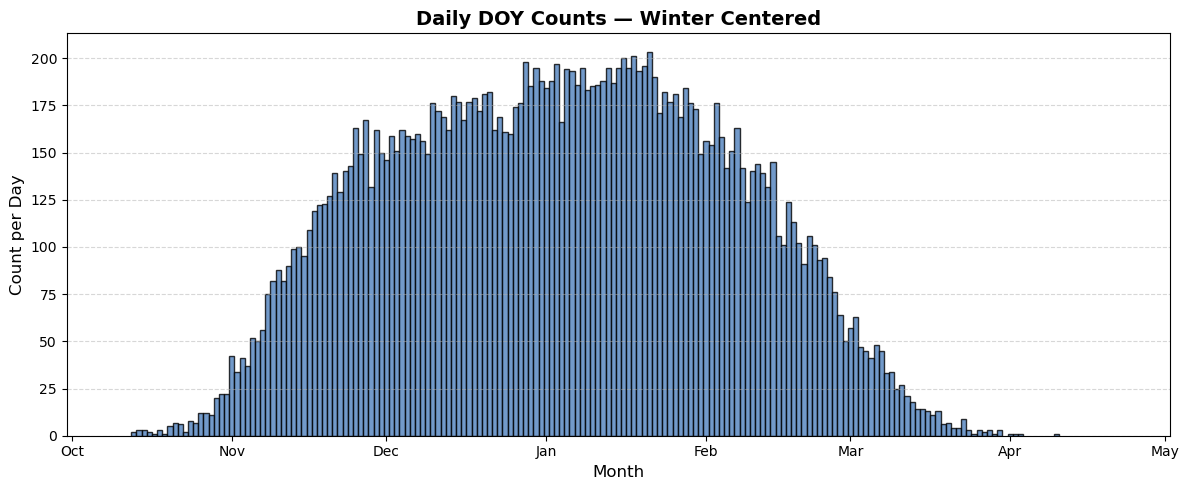

In [29]:
plot_oct_apr_centered(LEE_vl_dl)

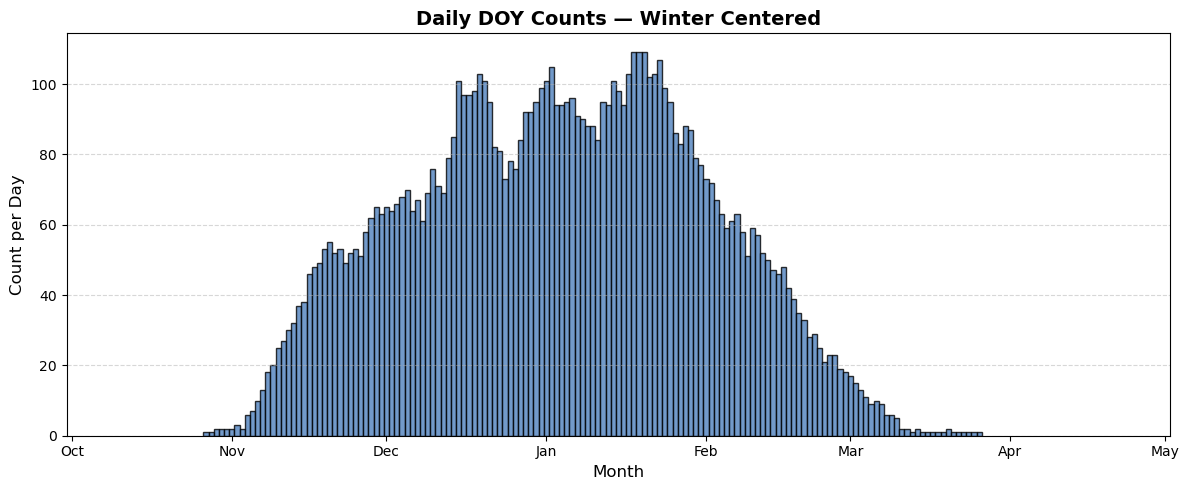

In [30]:
plot_oct_apr_centered(LEE_7_dl)

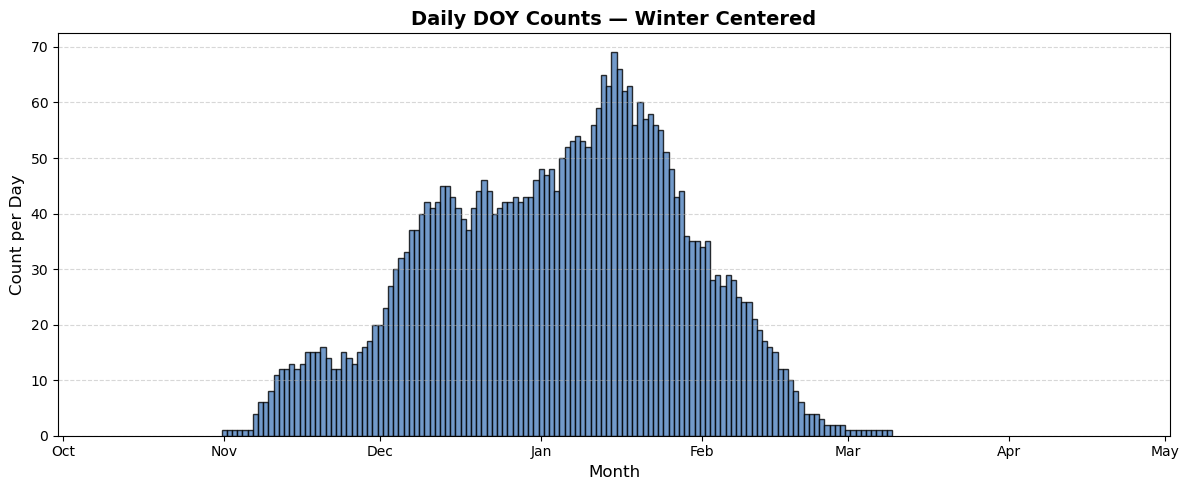

In [31]:
plot_oct_apr_centered(LEE_14_dl)

### Check how the LEE Days are distributed over the modells

In [32]:
# Add number of runs to the DataFrame
Nr_of_runs = LEE_vl.groupby('ESM')['ESM_run'].nunique()
LEE_vl['Nr_of_runs'] = LEE_vl['ESM'].map(Nr_of_runs)
LEE_vl

LEE_all_comp = LEE_vl.copy()


LEE_all_comp['LEE_vl_dur_sum'] = LEE_all_comp.groupby('ESM')['duration'].transform('sum')
LEE_all_comp = LEE_all_comp.drop_duplicates(subset=['ESM', 'LEE_vl_dur_sum'])
# LEE_all_comp['Nr_of_runs'] = Nr_of_runs.values

LEE_all_comp['LEE_vl_dur_avg'] = LEE_all_comp['LEE_vl_dur_sum'] / LEE_all_comp['Nr_of_runs']
# Remove most of the columns except for the ones we want to keep
LEE_all_comp = LEE_all_comp[['ESM', 'Nr_of_runs', 'LEE_vl_dur_sum', 'LEE_vl_dur_avg']]
LEE_all_comp

LEE_dat_temp = LEE_dat.copy()
LEE_dat_temp['LEE_dat_dur_sum'] = LEE_dat_temp.groupby('ESM')['duration'].transform('sum')
LEE_dat_temp = LEE_dat_temp.drop_duplicates(subset=['ESM', 'LEE_dat_dur_sum'])
LEE_dat_temp
# Join the two DataFrames on 'ESM'
LEE_all_comp = LEE_all_comp.merge(LEE_dat_temp[['ESM', 'LEE_dat_dur_sum']], on='ESM', how='left')
LEE_all_comp['LEE_dat_dur_avg'] = LEE_all_comp['LEE_dat_dur_sum'] / LEE_all_comp['Nr_of_runs']
LEE_all_comp

LEE_7_temp = LEE_7.copy()
LEE_7_temp['LEE_7_dur_sum'] = LEE_7_temp.groupby('ESM')['duration'].transform('sum')
LEE_7_temp = LEE_7_temp.drop_duplicates(subset=['ESM', 'LEE_7_dur_sum'])
LEE_7_temp

# Join the two DataFrames on 'ESM'
LEE_all_comp = LEE_all_comp.merge(LEE_7_temp[['ESM', 'LEE_7_dur_sum']], on='ESM', how='left')
LEE_all_comp['LEE_7_dur_avg'] = LEE_all_comp['LEE_7_dur_sum'] / LEE_all_comp['Nr_of_runs']


LEE_14_temp = LEE_14.copy()
LEE_14_temp['LEE_14_dur_sum'] = LEE_14_temp.groupby('ESM')['duration'].transform('sum')
LEE_14_temp = LEE_14_temp.drop_duplicates(subset=['ESM', 'LEE_14_dur_sum'])
# Join the two DataFrames on 'ESM'
LEE_all_comp = LEE_all_comp.merge(LEE_14_temp[['ESM', 'LEE_14_dur_sum']], on='ESM', how='left')
LEE_all_comp['LEE_14_dur_avg'] = LEE_all_comp['LEE_14_dur_sum'] / LEE_all_comp['Nr_of_runs']

LEE_all_comp

,ESM,Nr_of_runs,LEE_vl_dur_sum,LEE_vl_dur_avg,LEE_dat_dur_sum,LEE_dat_dur_avg,LEE_7_dur_sum,LEE_7_dur_avg,LEE_14_dur_sum,LEE_14_dur_avg
0,ACCESS-CM2,3,642,214.000000,642,214.000000,280,93.333333,112.0,37.333333
1,BCC-CSM2-MR,1,229,229.000000,229,229.000000,119,119.000000,84.0,84.000000
2,CESM2,3,297,99.000000,297,99.000000,154,51.333333,28.0,9.333333
3,EC-Earth3,53,8333,157.226415,8333,157.226415,3290,62.075472,1204.0,22.716981
4,ERA5_week,1,183,183.000000,183,183.000000,70,70.000000,28.0,28.000000
5,GFDL-ESM4,1,165,165.000000,165,165.000000,70,70.000000,NaN,NaN
6,KACE-1-0-G,3,330,110.000000,330,110.000000,147,49.000000,56.0,18.666667
7,MPI-ESM1-2-HR,10,2431,243.100000,2431,243.100000,1078,107.800000,602.0,60.200000
8,MRI-ESM2-0,5,716,143.200000,716,143.200000,315,63.000000,154.0,30.800000
9,TaiESM1,1,141,141.000000,141,141.000000,49,49.000000,14.0,14.000000


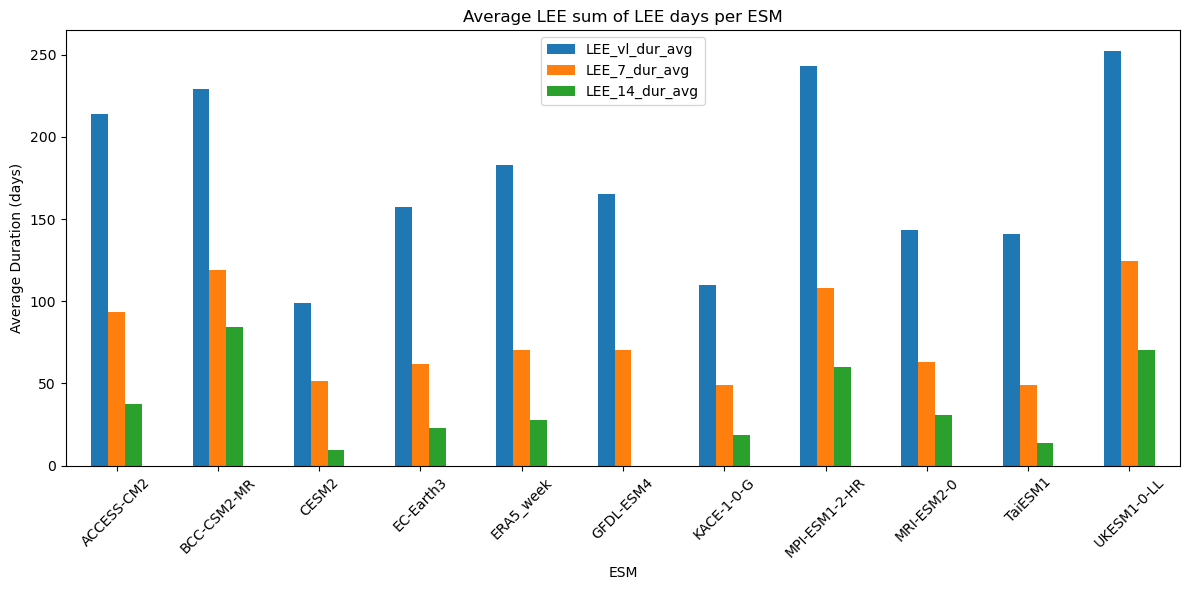

In [33]:
# Make a bar plot of the average durations
LEE_all_comp.set_index('ESM')[['LEE_vl_dur_avg', 'LEE_7_dur_avg', 'LEE_14_dur_avg']].plot(kind='bar', figsize=(12, 6))
plt.title('Average LEE sum of LEE days per ESM')
plt.ylabel('Average Duration (days)')
plt.xlabel('ESM')
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('/climca/people/onennecke/model_output/bias_corrected_masked/winter_data/adjusted/LEE_durations_comparison.png', dpi=300)
plt.show()

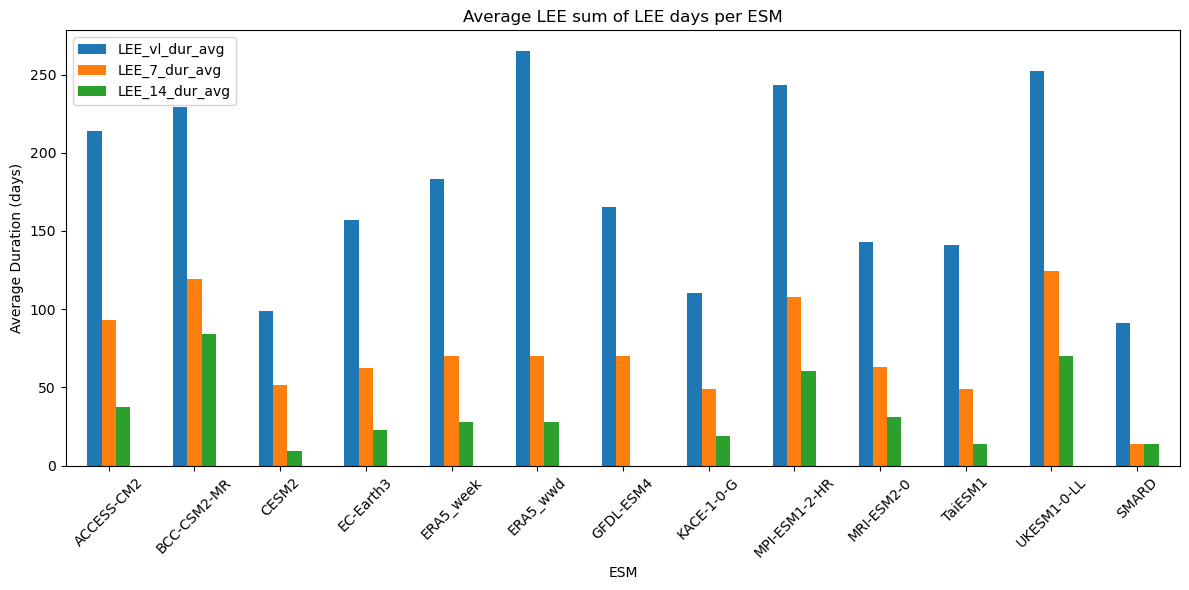

In [19]:
# Make a bar plot of the average durations
LEE_all_comp.set_index('ESM')[['LEE_vl_dur_avg', 'LEE_7_dur_avg', 'LEE_14_dur_avg']].plot(kind='bar', figsize=(12, 6))
plt.title('Average LEE sum of LEE days per ESM')
plt.ylabel('Average Duration (days)')
plt.xlabel('ESM')
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('/climca/people/onennecke/model_output/bias_corrected_masked/winter_data/adjusted/LEE_durations_comparison.png', dpi=300)
plt.show()

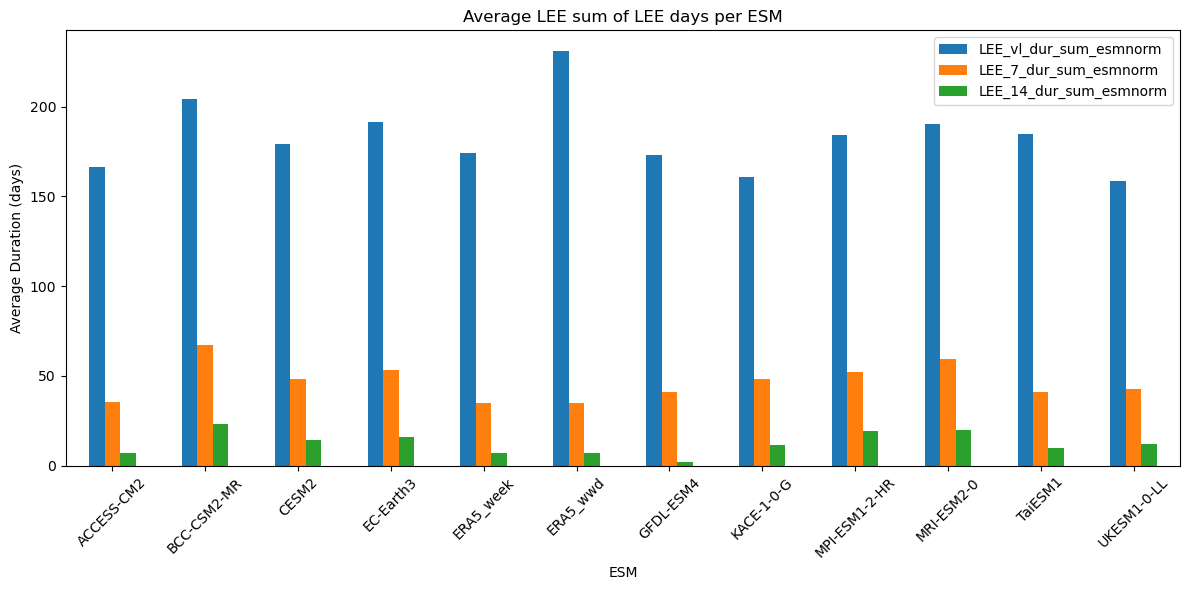

In [58]:
# Make a bar plot of the average durations
LEE_all_comp.set_index('ESM')[['LEE_vl_dur_sum_esmnorm', 'LEE_7_dur_sum_esmnorm', 'LEE_14_dur_sum_esmnorm']].plot(kind='bar', figsize=(12, 6))
plt.title('Average LEE sum of LEE days per ESM')
plt.ylabel('Average Duration (days)')
plt.xlabel('ESM')
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('/climca/people/onennecke/model_output/bias_corrected_masked/winter_data/adjusted/LEE_durations_comparison.png', dpi=300)
plt.show()

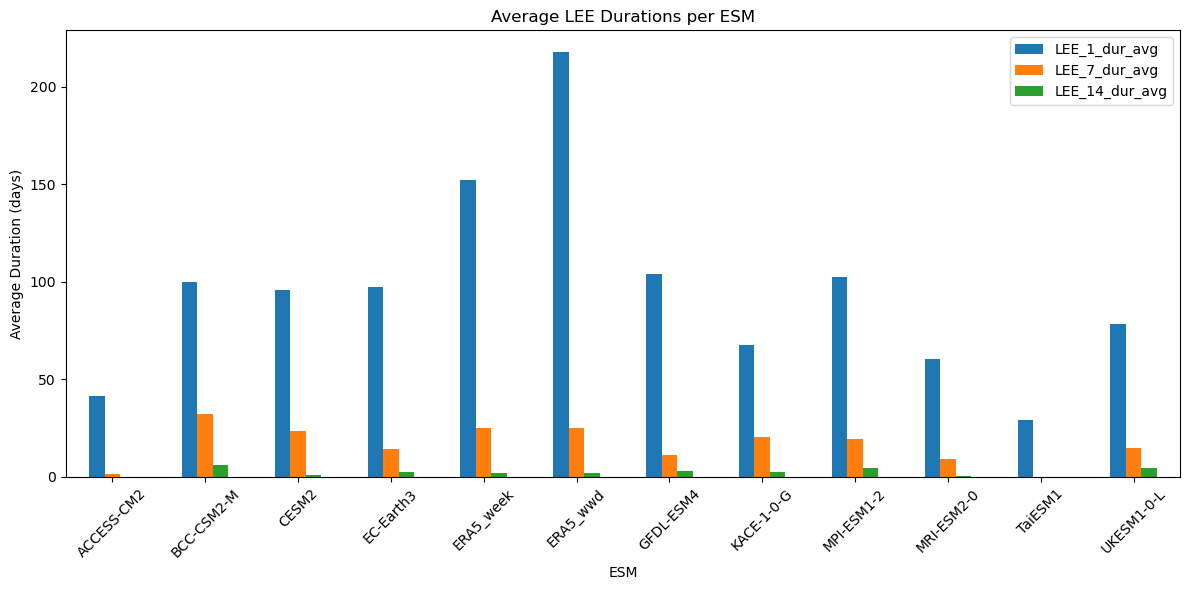

In [ ]:
# Make a bar plot of the average durations
LEE_all_comp.set_index('ESM')[['LEE_vl_dur_sum_esmnorm', 'LEE_7_dur_sum_esmnorm', 'LEE_14_dur_sum_esmnorm']].plot(kind='bar', figsize=(12, 6))
plt.title('Average LEE Durations per ESM')
plt.ylabel('Average Duration (days)')
plt.xlabel('ESM')
plt.xticks(rotation=45)
plt.tight_layout()
# plt.savefig('/climca/people/onennecke/model_output/bias_corrected_masked/winter_data/adjusted/LEE_durations_comparison.png', dpi=300)
plt.show()

----

### Old Code

In [20]:
# Identify events which are close to each other
for i in range(LEE_7.shape[0]-1):
    diff = LEE_7['date_start'][i + 1] - LEE_7['date_end'][i]
    if diff < pd.Timedelta(days=7) and diff > pd.Timedelta(days=0) and LEE_7['ESM_run'][i] == LEE_7['ESM_run'][i + 1]:
        print(diff, ':', i)
        print(LEE_7['date_end'][i], LEE_7['date_start'][i + 1])
        # print(i)

2 days 00:00:00 : 39
2020-12-19 12:00:00 2020-12-21 12:00:00
4 days 00:00:00 : 50
2015-01-07 12:00:00 2015-01-11 12:00:00
2 days 00:00:00 : 92
2019-12-06 12:00:00 2019-12-08 12:00:00
5 days 00:00:00 : 110
2017-12-24 12:00:00 2017-12-29 12:00:00
2 days 00:00:00 : 145
2021-12-21 12:00:00 2021-12-23 12:00:00
3 days 00:00:00 : 163
2021-01-05 12:00:00 2021-01-08 12:00:00
4 days 00:00:00 : 189
2020-12-14 12:00:00 2020-12-18 12:00:00
3 days 00:00:00 : 197
2019-12-30 12:00:00 2020-01-02 12:00:00
3 days 00:00:00 : 225
2016-12-26 12:00:00 2016-12-29 12:00:00
6 days 00:00:00 : 245
2020-02-06 12:00:00 2020-02-12 12:00:00
2 days 00:00:00 : 251
2015-12-22 12:00:00 2015-12-24 12:00:00
5 days 00:00:00 : 262
2019-12-27 12:00:00 2020-01-01 12:00:00
2 days 00:00:00 : 263
2020-01-03 12:00:00 2020-01-05 12:00:00
2 days 00:00:00 : 264
2020-01-07 12:00:00 2020-01-09 12:00:00
5 days 00:00:00 : 265
2020-01-17 12:00:00 2020-01-22 12:00:00
2 days 00:00:00 : 273
2021-12-19 12:00:00 2021-12-21 12:00:00
3 days 00:0

In [22]:
LEE_7[39:43]

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,ESM,ESM_run,winter,day_of_winter
39,2020-12-19 12:00:00,2020-12-19 12:00:00,2020-12-19 12:00:00,1079,1079,1079,1,1423.572743,1423.572743,0.0,1423.572743,EC-Earth3,EC-Earth3_r108i1p1f1,2020,80
40,2020-12-21 12:00:00,2020-12-21 12:00:00,2020-12-21 12:00:00,1081,1081,1081,1,1188.854333,1188.854333,0.0,1188.854333,EC-Earth3,EC-Earth3_r108i1p1f1,2020,82
41,2016-11-22 12:00:00,2016-11-22 12:00:00,2016-11-22 12:00:00,324,324,324,1,1375.515610,1375.515610,0.0,1375.515610,EC-Earth3,EC-Earth3_r109i1p1f1,2016,53
42,2019-12-11 12:00:00,2019-12-11 12:00:00,2019-12-11 12:00:00,889,889,889,1,1401.143383,1401.143383,0.0,1401.143383,EC-Earth3,EC-Earth3_r109i1p1f1,2019,72


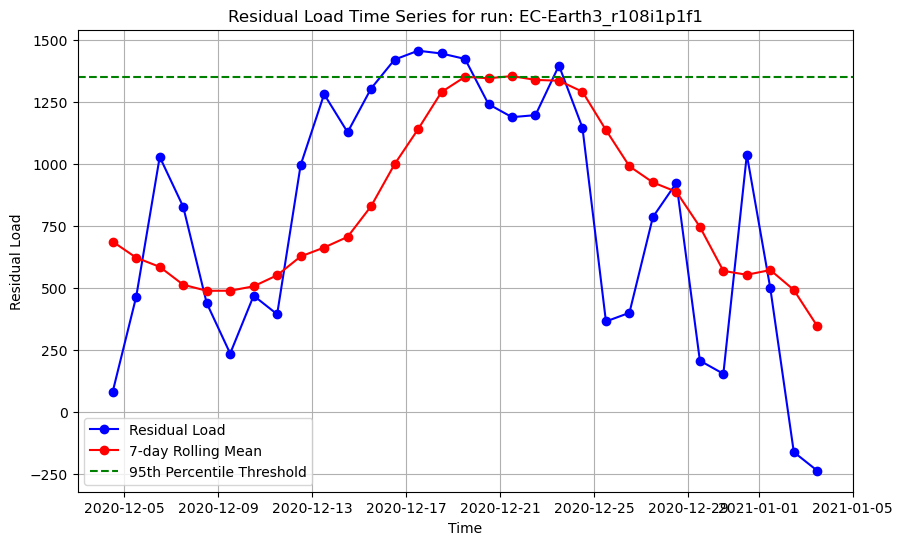

In [23]:
LEE = LEE_7
evt = 39
box = 15


# Extract the data for the specified range
RL_plot = RL.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]
rolling_mean_plot = RL_mov_avg_7.sel(ESM_run=LEE['ESM_run'][evt])[LEE['index_start'][evt]-box: LEE['index_end'][evt]+1+box]

# Plot using matplotlib
plt.figure(figsize=(10, 6))
plt.plot(RL_plot['time'], RL_plot, marker='o', linestyle='-', color='b', label='Residual Load')
plt.plot(rolling_mean_plot['time'], rolling_mean_plot, marker='o', linestyle='-', color='r', label='7-day Rolling Mean')
# Threshold
plt.axhline(y=threshold, color='g', linestyle='--', label='95th Percentile Threshold')
plt.xlabel('Time')
plt.ylabel('Residual Load')
plt.title(f'Residual Load Time Series for run: {LEE['ESM_run'][evt]}')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
# Old code without rolling mean

minDuration = 7 # days
t = RL['time'].values

# Find all LEE events of duration >= minDuration
for i in range(len(RL.ESM)):
    
    for ev in range(1,n_events+1):
        # print(ev)
        event_duration = (events[i] == ev).sum() 
        if event_duration < minDuration:
            continue
        print(RL.ESM_run[i].values)
        # print(event_duration)
        LEE['date_start'].append(t[np.where(events[i] == ev)[0][0]])
        LEE['date_end'].append(t[np.where(events[i] == ev)[0][-1]])
        LEE['ESM'].append(str(RL.ESM[i].values))
        LEE['ESM_run'].append(str(RL.ESM_run[i].values))
        LEE['winter'].append(RL.winter_year[i].values)
        LEE_start = np.where(t==LEE['date_start'][-1])[0][0]
        # print(LEE_start)
        LEE_end = np.where(t==LEE['date_end'][-1])[0][0]
        # print(LEE_end)
        LEE['index_start'].append(LEE_start)
        LEE['index_end'].append(LEE_end)
        RL_run = RL.sel(ESM_run = RL.ESM_run[i]).values # RL timeseries of the event
        RL_LEE = RL_run[LEE_start : LEE_end + 1] # RL timeseries
        print(RL_LEE)
        LEE_peak = np.argmax(RL_LEE)
        print('LEE Peak', LEE_peak)
        LEE['date_peak'].append(LEE['date_start'][-1] + LEE_peak)
        print(LEE['date_peak'][-1])
        LEE['index_peak'].append(LEE_start + LEE_peak)
        print(LEE['index_peak'][-1])
        # LEE Duration
        LEE['duration'].append(len(RL_LEE))
        print('Duration:', LEE['duration'][-1])
        # LEE Intensity metrics
        LEE['RL_max'].append(RL_LEE[LEE_peak])
        print('RL_max:', LEE['RL_max'][-1])
        LEE['RL_mean'].append(RL_LEE.mean())
        print('RL_mean:', LEE['RL_mean'][-1])
        LEE['RL_var'].append(np.sqrt(RL_LEE.var()))
        print('RL_var:', LEE['RL_var'][-1])
        LEE['RL_cumulative'].append(RL_LEE.sum()) # energy deficit or drought severity
        print('RL_cumulative:', LEE['RL_cumulative'][-1])
        # break
    

UKESM1-0-LL_r4i1p1f2
[1362.02202    1426.84594281 1403.19686189 1411.79696924 1411.13093176
 1438.61170868 1382.75334765]
LEE Peak 5
2015-01-23T12:00:00.000000005
27
Duration: 7
RL_max: 1438.6117086791608
RL_mean: 1405.1939688609311
RL_var: 24.011269786239097
RL_cumulative: 9836.357782026518
UKESM1-0-LL_r4i1p1f2
[1355.6347917  1400.32245918 1373.75876901 1390.95103538 1406.78897509
 1423.62005802 1380.29133016]
LEE Peak 5
2019-12-02T12:00:00.000000005
885
Duration: 7
RL_max: 1423.6200580209427
RL_mean: 1390.1953455057615
RL_var: 20.902398680347783
RL_cumulative: 9731.36741854033
UKESM1-0-LL_r4i1p1f2
[1373.4060436  1401.99949651 1493.61290014 1482.99039703 1438.34592673
 1365.58574216 1368.49068761 1484.80195225]
LEE Peak 2
2020-12-19T12:00:00.000000002
1081
Duration: 8
RL_max: 1493.6129001439044
RL_mean: 1426.1541432545234
RL_var: 52.116052006315186
RL_cumulative: 11409.233146036187
UKESM1-0-LL_r4i1p1f2
[1370.62007933 1388.50287797 1429.56230377 1398.48584854 1377.94712584
 1409.565378

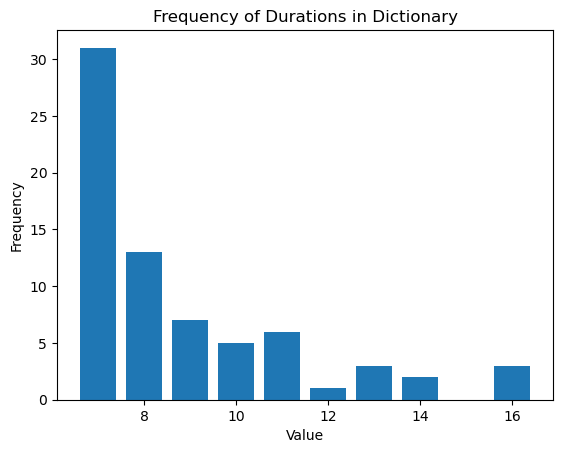

In [28]:
from collections import Counter
# Count how often each value occurs
value_counts = Counter(LEE['duration'])

# Extract the values and their counts
values = list(value_counts.keys())
counts = list(value_counts.values())

# Create a bar plot
plt.bar(values, counts)

# Add title and labels
plt.title('Frequency of Durations in Dictionary')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the plot
plt.show()

In [29]:
value_counts

Counter({7: 31, 8: 13, 9: 7, 11: 6, 10: 5, 16: 3, 13: 3, 14: 2, 12: 1})

In [32]:
from collections import Counter
# Count how often each value occurs
value_counts = Counter(LEE['ESM'])

# Extract the values and their counts
values = list(value_counts.keys())
counts = list(value_counts.values())

runs = dict(model = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'EC-Earth3-Veg', 'GFDL-ESM4', 'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1', 'UKESM1-0-LL'],
         run = [3, 1, 3, 58, 1, 1, 3, 10, 5, 1, 19])

df = pd.DataFrame(runs)
df['count'] = df['model'].map(value_counts)
df['relative'] = df['count'] / df['run']
df

,model,run,count,relative
0,ACCESS-CM2,3,211,70.333333
1,BCC-CSM2-MR,1,67,67.000000
2,CESM2,3,91,30.333333
3,EC-Earth3,58,2240,38.620690
4,EC-Earth3-Veg,1,0,0.000000
5,GFDL-ESM4,1,52,52.000000
6,KACE-1-0-G,3,81,27.000000
7,MPI-ESM1-2-HR,10,779,77.900000
8,MRI-ESM2-0,5,166,33.200000
9,TaiESM1,1,48,48.000000


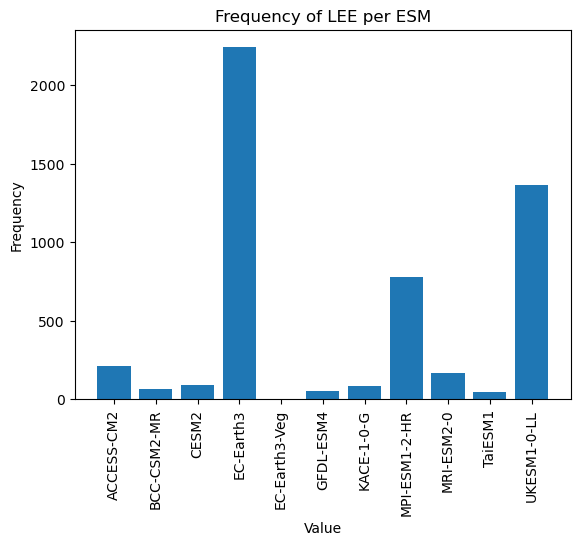

In [46]:
# Create a bar plot
plt.bar(df['model'], df['count'])

# Add title and labels
plt.title('Frequency of LEE per ESM')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
# Show the plot
plt.show()

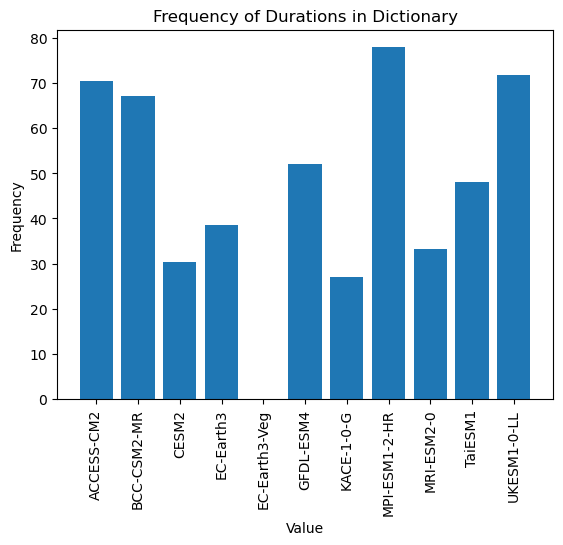

In [ ]:
# Create a bar plot
plt.bar(df['model'], df['relative'])

# Add title and labels
plt.title('Mean Frequency of LEE in ESM')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
# Show the plot
plt.show()

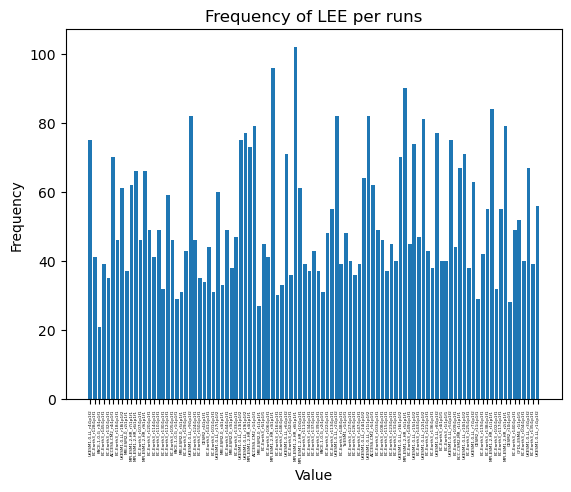

In [47]:
from collections import Counter
# Count how often each value occurs
value_counts = Counter(LEE['ESM_run'])

# Extract the values and their counts
values = list(value_counts.keys())
counts = list(value_counts.values())

# Create a bar plot
plt.bar(values, counts)

# Add title and labels
plt.title('Frequency of LEE per runs')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.xticks(rotation=90, fontsize=3)

# Show the plot
plt.show()

In [22]:
LEE['duration'][0]

1

In [17]:
len(LEE['date_start'])

5098

In [ ]:
# RL_run = RL.sel(ESM_run = RL.ESM_run[]).values # RL timeseries of the event
# RL_LEE = RL_run[tt_start : tt_end + 1] # RL timeseries
# print(RL_LEE)

[ 158.64572976 1101.632428   1192.03642035 1222.05022456 1166.72837583
 1201.17447734 1294.25195143 1276.89910241 1370.90321842  983.0898243
 1093.8583566   768.77892421 1256.19375004 1013.36348419  969.54925136
  474.07758187]


In [19]:
for i in range(len(LEE['date_start'])):
    print(LEE['ESM'][i])
    print(LEE['ESM_run'][i])
    print(LEE['winter'][i])
    print(LEE['date_start'][i])
    print(LEE['date_end'][i])


# np.unique(LEE['date_start'])

UKESM1-0-LL
UKESM1-0-LL_r18i1p1f2
[2014 2014 2014 ... 2024 2024 2024]
2016-01-14T12:00:00.000000000
2016-01-24T12:00:00.000000000
UKESM1-0-LL
UKESM1-0-LL_r13i1p1f2
[2014 2014 2014 ... 2024 2024 2024]
2016-01-08T12:00:00.000000000
2016-01-23T12:00:00.000000000
UKESM1-0-LL
UKESM1-0-LL_r19i1p1f2
[2014 2014 2014 ... 2024 2024 2024]
2019-01-21T12:00:00.000000000
2019-01-30T12:00:00.000000000
MPI-ESM1-2-HR
MPI-ESM1-2-HR_r4i1p1f1
[2014 2014 2014 ... 2024 2024 2024]
2020-12-02T12:00:00.000000000
2020-12-15T12:00:00.000000000
MPI-ESM1-2-HR
MPI-ESM1-2-HR_r10i1p1f1
[2014 2014 2014 ... 2024 2024 2024]
2023-12-01T12:00:00.000000000
2023-12-11T12:00:00.000000000
EC-Earth3
EC-Earth3_r134i1p1f1
[2014 2014 2014 ... 2024 2024 2024]
2021-12-29T12:00:00.000000000
2022-01-07T12:00:00.000000000
EC-Earth3
EC-Earth3_r113i1p1f1
[2014 2014 2014 ... 2024 2024 2024]
2018-12-21T12:00:00.000000000
2018-12-31T12:00:00.000000000
UKESM1-0-LL
UKESM1-0-LL_r2i1p1f2
[2014 2014 2014 ... 2024 2024 2024]
2018-01-01T12:00:00.

In [ ]:
# # np.where(t==LEE['date_start'][1])[0][0]
# tt_start = np.where(t==LEE['date_start'][1])[0][0]
# print(tt_start)
# tt_end = np.where(t==LEE['date_end'][1])[0][0]
# print(tt_end)
# LEE['index_start'].append(tt_start)
# LEE['index_end'].append(tt_end)
# RL_run = RL.sel(ESM_run = RL.ESM_run[1]).values # RL timeseries of the event
# RL_LEE = RL_run[tt_start : tt_end + 1] # RL timeseries
# print(RL_LEE)
# tt_peak = np.argmax(RL_LEE)
# # print(tt_peak)

189
204
[ 866.01605503  978.79976812  978.1085741   766.14326346  313.90692019
  621.47068534 1062.72773477 1327.46688984 1367.54710415 1193.53293817
 1053.02655528 1208.94265281  981.18107694  625.57649208 1082.50865648
  979.61998489]


In [ ]:
# maybe:
LEE['prod_max'] = []
LEE['prod_mean'] = []
LEE['prod_var'] = []
LEE['prod_cumulative'] = []
LEE['demand_max'] = []
LEE['demand_mean'] = []
LEE['demand_var'] = []
LEE['demand_cumulative'] = []
LEE['pot_max'] = []
LEE['pot_mean'] = []
LEE['pot_var'] = []
LEE['pot_cumulative'] = []

189
204


In [ ]:
'''
# Link heat waves that occur before and after a short gap (gap must be no longer than maxGap)
if joinAcrossGaps:
    # Calculate gap length for each consecutive pair of events
    gaps = np.array(LEE['time_start'][1:]) - np.array(LEE['time_end'][0:-1]) - 1
    if len(gaps) > 0:
        while gaps.min() <= maxGap:
            # Find first short gap
            ev = np.where(gaps <= maxGap)[0][0]
            # Extend first LEE to encompass second LEE (including gap)
            LEE['time_end'][ev] = LEE['time_end'][ev+1]
            # Remove second event from record
            del LEE['time_start'][ev+1]
            del LEE['time_end'][ev+1]
            # Calculate gap length for each consecutive pair of events
            gaps = np.array(LEE['time_start'][1:]) - np.array(LEE['time_end'][0:-1]) - 1
            if len(gaps) == 0:
                break
'''


'''
# Fix categories
tt_peakCat = np.argmax(LEE_relThreshNorm)
cats = np.floor(1. + LEE_relThreshNorm)
LEE['category'].append(categories[np.min([cats[tt_peakCat], 4]).astype(int) - 1])
LEE['duration_moderate'].append(np.sum(cats == 1.))
LEE['duration_strong'].append(np.sum(cats == 2.))
LEE['duration_severe'].append(np.sum(cats == 3.))
LEE['duration_extreme'].append(np.sum(cats >= 4.))
'''


array([1244.5034235 , 1321.65036059, 1314.3476472 , ..., 1431.4471573 ,
       1439.09306053, 1391.82968321])

## Calculation of SRLI

In [ ]:
import xarray as xr
import dask.array as da
import numpy as np
from scipy.stats import norm

def compute_srli(data_array, eps=1e-4): #1/(2*180180)
    """
    Compute the SRLI (Standardised Residual Load Index) over the full dataset,
    while keeping the shape and metadata of the input xarray DataArray.

    Parameters:
    - data_array (xarray.DataArray): input residual load (shape: ESM_run x time)

    Returns:
    - srli (xarray.DataArray): same shape as input, with SRLI values
    """
    # Compute ECDF ranks using Dask
    def ecdf_rank(values):
        # Sort the values
        sorted_vals = np.sort(values)
        # Use searchsorted to get the ECDF
        ranks = np.searchsorted(sorted_vals, values, side="right")
        ecdf_vals = (ranks + 1) / (len(values) + 1)
        return np.clip(ecdf_vals, eps, 1 - eps)  # avoid 0 and 1
    
    
    # Compute ECDF on full dataset (across all dimensions)
    ecdf = data_array.copy(data=da.map_blocks(
        lambda block: ecdf_rank(block.flatten()).reshape(block.shape),
        data_array.data,
        dtype=float
    ))

    # Apply inverse normal CDF (probit function)
    srli = xr.apply_ufunc(
        norm.ppf,
        ecdf,
        dask='parallelized',
        output_dtypes=[float]
    )

    # Rename the result
    srli.name = "SRLI"

    return srli


In [89]:
srli_tst = compute_srli(RL)

In [ ]:
# Time series of "True" when threshold is exceeded, "False" otherwise

exceed_bool = xr.where(srli_tst.values > 1.64, True, False)

# Find contiguous regions of exceed_bool = True
events, n_events = ndimage.label(exceed_bool)

In [74]:
events

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int32)

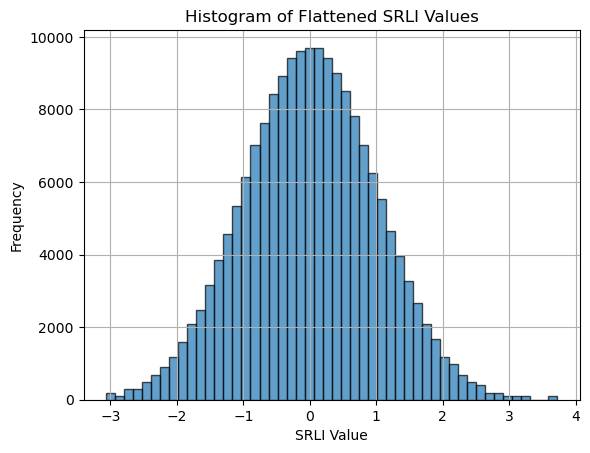

In [90]:
import matplotlib.pyplot as plt

# Flatten the SRLI values and create a histogram
plt.hist(srli_tst.values.flatten(), bins=50, edgecolor='k', alpha=0.7)
plt.xlabel('SRLI Value')
plt.ylabel('Frequency')
plt.title('Histogram of Flattened SRLI Values')
plt.grid(True)
plt.show()

## Old Code

#### SRLI for individual run

In [ ]:
import numpy as np
from scipy.stats import norm

def calculate_srli(residual_load_series):
    """
    Calculate the Standardised Residual Load Index (SRLI) from a series of residual load values.
    
    Parameters:
    - residual_load_series: pd.Series or np.array of residual load values

    Returns:
    - srli_values: np.array of SRLI values
    """
    # Ensure data is a numpy array
    data = np.array(residual_load_series)
    
    # Rank the data to calculate the empirical CDF
    sorted_data = np.sort(data)
    ranks = np.searchsorted(sorted_data, data, side='right')
    empirical_cdf = (ranks + 1) / (len(data) + 1)

    # Apply the inverse of the standard normal CDF (probit)
    srli_values = norm.ppf(empirical_cdf)
    
    return srli_values